***
# Notes
***
- Weekly aggregated data
- ~~61% accuracy for Random Forest (test is 62%, so higher for some reason?)~~
    - reaching >90% pretty easily with hyptertuning
    - removed day & week numbers - still successful
    - testing removal of pickup_zones
- Analysis takeaways (no particular order):
    1. Took out `ratecode` & `payment_type` to make the data smaller; doesn't seem to help determine ride demand
    2. `route` is most important (`pickup_zone` + `dropoff_zone`)
    3. `service_zone _route` only helpful when `Yellow Zone -> Yellow Zone` - *data dominance*, and this may be overlapping with `route` data
    4. Only 1 `vendor` is important (`Curb Mobility, LLC`) - *data dominance*
    5. `month` not really that important

### TO DO 
1. ~~Look at residuals - funny clusterings happening~~
    - added `min_samples = 2` and changed `max_depth` from 10 -> 25
2. ~~Include weather reports: <https://www.extremeweatherwatch.com/cities/new-york/year-2024>~~
    - changed to updated weather API, see `./weather_data.ipynb`, or `./dataset.py` function `read_weather_data()`
3. Plot out relations: dominance of `vendor`, all the different `route`s, dominance of `service_zone` (we need arguments to remove what we can)
4. Figure out lag features (`weather` and `prev_weather` maybe?)
5. NYC holidays needed



>> lag demand for previous time of day instead
>> inclue pickup & dropoff zone


In [1]:
import dataset # local import
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

seed = 123
df = dataset.read_agg(month_start=1, month_end=12)
print(df.info())
print(df.head(3))

reading data for month 1
reading data for month 2
reading data for month 3
reading data for month 4
reading data for month 5
reading data for month 6
reading data for month 7
reading data for month 8
reading data for month 9
reading data for month 10
reading data for month 11
reading data for month 12
collecting weather data


/home/kv/education/ml/groupwork/models/ride_demand/dataset.py:297: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wthr.replace('T', 0, inplace=True)
/home/kv/education/ml/groupwork/models/ride_demand/dataset.py:298: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wthr.replace('M', np.nan, inplace=True)


collecting calendar data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5128903 entries, 0 to 5128902
Data columns (total 22 columns):
 #   Column            Dtype         
---  ------            -----         
 0   pickup_month      int32         
 1   pickup_week       UInt32        
 2   pickup_date       datetime64[ns]
 3   pickup_dow        int32         
 4   time_of_day       object        
 5   pickup_zone       object        
 6   dropoff_zone      object        
 7   route             object        
 8   total_ride_count  int64         
 9   avg_fare_amount   float64       
 10  temp_high         int64         
 11  precip            float64       
 12  snow              float64       
 13  max_wind_speed    float64       
 14  cloud_coverage    float64       
 15  fog               bool          
 16  low_vis           bool          
 17  thunder           bool          
 18  hail              bool          
 19  freezing_rain     bool          
 20  haze              boo

In [2]:
import pandas as pd

# No need for categorical ordering or complex sorting
daily = df.groupby(['pickup_date', 'time_of_day', 'route'], as_index=False)['total_ride_count'].sum()

# Sort by date to ensure proper shift across days
daily = daily.sort_values(['route', 'time_of_day', 'pickup_date'])

# Lag: same time_of_day, previous day
daily['lag_demand'] = daily.groupby(['route', 'time_of_day'])['total_ride_count'].shift(1)

# Check result
daily[daily['route'] == "Upper East Side North to Upper East Side South"]
df = df.merge(
    daily[['route', 'pickup_date', 'time_of_day', 'lag_demand']],
    on=['time_of_day', 'route', 'pickup_date'],
    how='left'
)
df['lag_demand'] = df['lag_demand'].fillna(0)

# Preprocessing

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Recast object types -> category (just to be sure)
df = df.astype({
    'pickup_zone': 'category',
    'route': 'category',
    'time_of_day': 'category',
    'hail': 'bool',  
    'freezing_rain': 'bool',  
    'holiday': 'category',
})

# Remove waste columns
df = df.drop(errors='ignore', columns=[
    'dropoff_zone',
    'pickup_date',
    'service_route',
    'pickup_service_zone',
    'dropoff_service_zone',
    'pickup_week',
    'pickup_day',  
    'avg_fare_amount',        
    'hail',
    'freezing_rain',
    'haze',
])

# These columns only have a few categories
#
# => onehot encoding is okay
columns_to_onehot_encode = [
    'pickup_dow',
    'time_of_day',
]

# These columns have LOADS of categories
#
# => ordinal encoding is needed             <---- not doing this gives 500GB encoded dataset
#``
# (tried TargetEncoder, but still ended up at 22GB - sticking to ordinal)
columns_to_ordinal_encode = [
    'pickup_zone',
    'route',
    'holiday',
]

# Split `y` BEFORE pipeline
y = df['total_ride_count']
X = df.drop(columns=['total_ride_count'])

# scaler_lag = StandardScaler()
# X['lag_demand'] = scaler_lag.fit_transform(X['lag_demand'])

# Pipeline
#
# Transfroms the categorical columns to onehot-encoded types
pipeline = ColumnTransformer(
    transformers=[
        #                               +--- `sparse_output=True` stops the encoder duplicating data
        #                               |
        ("onehot", OneHotEncoder(sparse_output=True), columns_to_onehot_encode), 
        ("ordinal", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), columns_to_ordinal_encode),
    ],
    remainder='passthrough'
)
# pipeline.set_output(transform='pandas') # returning pandas cost too much memory
X_encoded = pipeline.fit_transform(X)

# Train vs Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=seed)

# Train vs Validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=seed)

# Training

In [9]:
from sklearn.ensemble import RandomForestRegressor

# Fine-tuned model
rf = RandomForestRegressor(
    n_jobs=1,           # parallel compute (using 2 as a default for standard laptop - do not recommed going higher than this)
                        # WARNING: increasing this will likely cause crashes
    random_state=seed,
    n_estimators=75,    # need reduced processing
    min_samples_leaf=2, # weird clustering around `250` & `400` predictions without this
    max_depth=25,       # maxdepth=25 worked very well for daily, but computation taking too long with `time_of_day`
                        # increased to 30 to account for onehote `time_of_day`
    # criterion='absolute_error' # very low values being mis-assigned    <-------    took too long to compute
)
rf.fit(X_train, y_train)

,n_estimators,75
,criterion,'squared_error'
,max_depth,25
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Results: Training & Validation

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Collection of regression scores
#
# 1. Mean Abs Err
# 2. Mean Sq Err
# 3. R Sq: percentage of variance explained
# 4. Residuals plot
# 5. Actual vs. Predicted plot
def analysis(y_true, y_pred):
    # Mean Absolute Error
    mae = mean_absolute_error(y_true, y_pred)
    print(f"Mean Absolute Error: \t{mae:.4f}")

    # Mean Squared Error
    mse = mean_squared_error(y_true, y_pred)
    print(f"Mean Squared Error: \t{mse:.4f}")

    # R squared
    r2 = r2_score(y_true, y_pred)
    print(f"R squared: \t\t{r2:.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Residuals
    residuals = y_true - y_pred
    ax[0].scatter(y_pred, residuals, alpha=.4)
    ax[0].axhline(0, color='black', linestyle='--')
    ax[0].set_xlabel("Predicted")
    ax[0].set_ylabel("Residuals")
    ax[0].set_title("Residuals")

    # Actual vs predicted
    ax[1].scatter(y_true, y_pred, alpha=.4)
    ax[1].set_xlabel("Actual")
    ax[1].set_ylabel("Predicted")
    ax[1].set_title("Actual vs. Predicted")

Mean Absolute Error: 	1.7495
Mean Squared Error: 	9.0306
R squared: 		0.9458
Mean Absolute Error: 	2.4151
Mean Squared Error: 	20.2139
R squared: 		0.8773


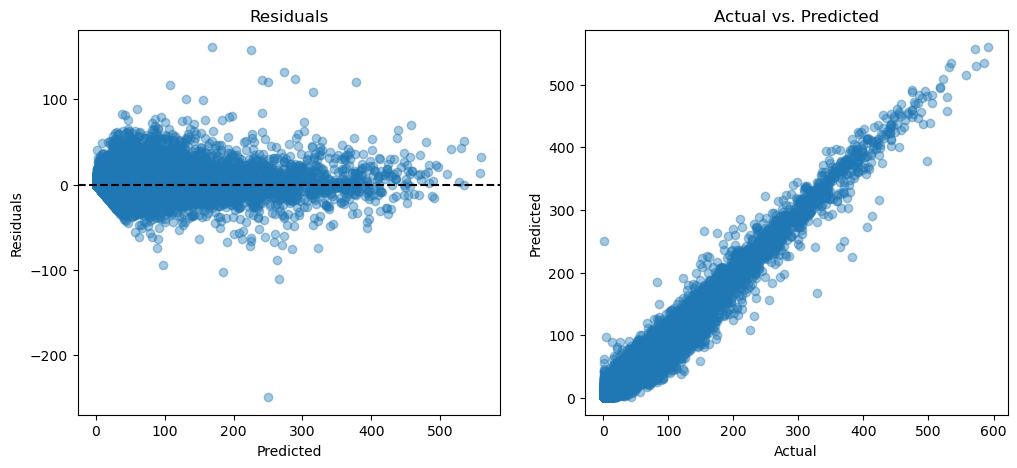

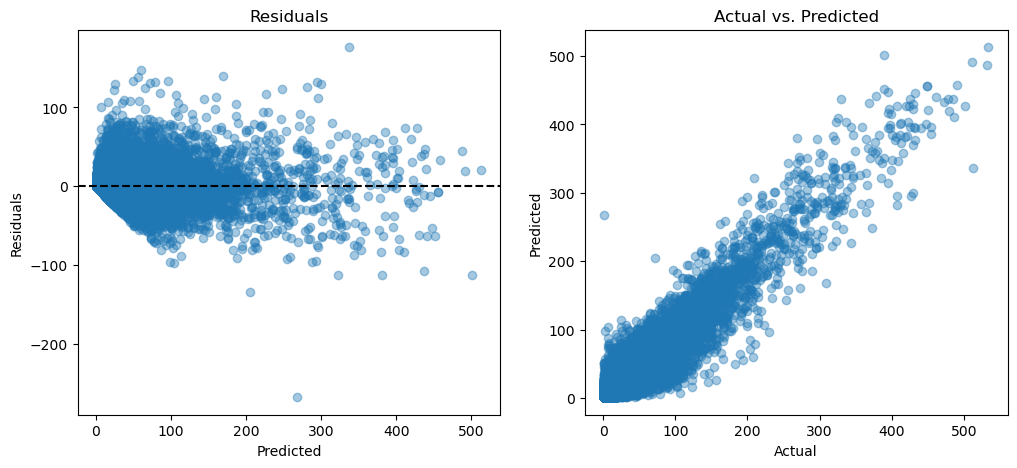

In [11]:
training_predictions = rf.predict(X_train)
analysis(y_train, training_predictions)

validation_predictions = rf.predict(X_val)
analysis(y_val, validation_predictions)

                             feature  importance
24             remainder__lag_demand    0.848143
13                    ordinal__route    0.045610
16              remainder__temp_high    0.011437
5               onehot__pickup_dow_5    0.010637
6               onehot__pickup_dow_6    0.010001
9     onehot__time_of_day_Late Night    0.008599
19         remainder__max_wind_speed    0.007657
15           remainder__pickup_month    0.007118
12              ordinal__pickup_zone    0.006638
20         remainder__cloud_coverage    0.006077
1               onehot__pickup_dow_1    0.005532
7        onehot__time_of_day_Evening    0.005251
0               onehot__pickup_dow_0    0.005040
17                 remainder__precip    0.003943
11  onehot__time_of_day_Morning Rush    0.003929
4               onehot__pickup_dow_4    0.002820
10        onehot__time_of_day_Midday    0.002685
8   onehot__time_of_day_Evening Rush    0.002566
14                  ordinal__holiday    0.002153
21                  

<Figure size 1200x1200 with 0 Axes>

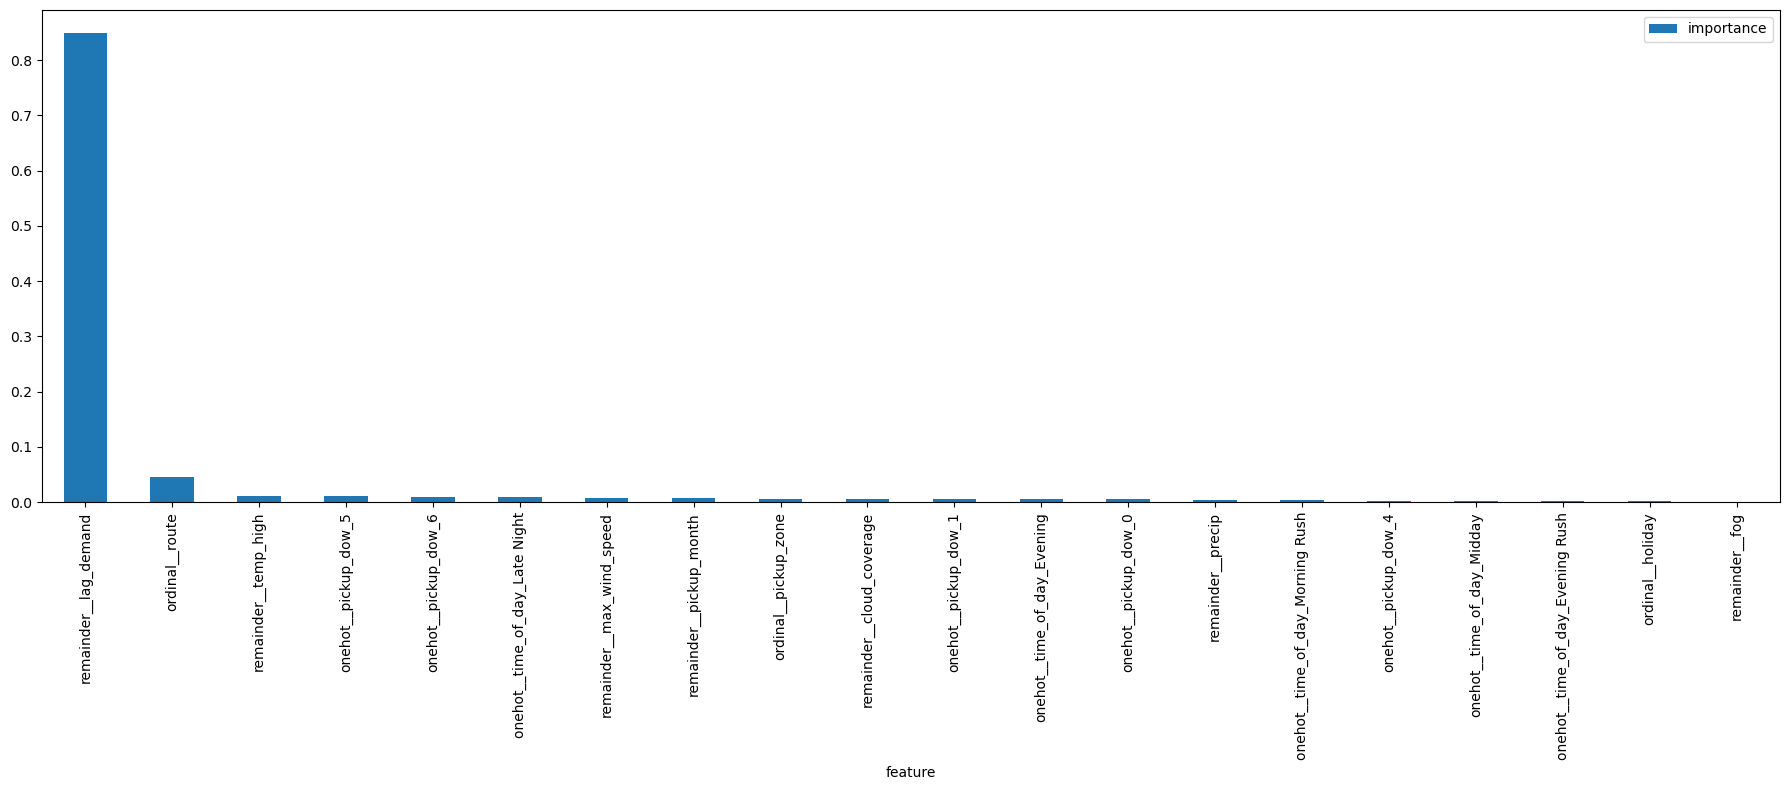

In [12]:
feature_names = pipeline.get_feature_names_out()
importances = rf.feature_importances_
feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)
print(feat_df)

plt.figure(figsize=(12,12))
feat_df.head(20).plot(kind='bar', x='feature', y='importance', figsize=(18, 8))
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

# Results: Testing

Mean Absolute Error: 	2.4065
Mean Squared Error: 	20.0398
R squared: 		0.8785


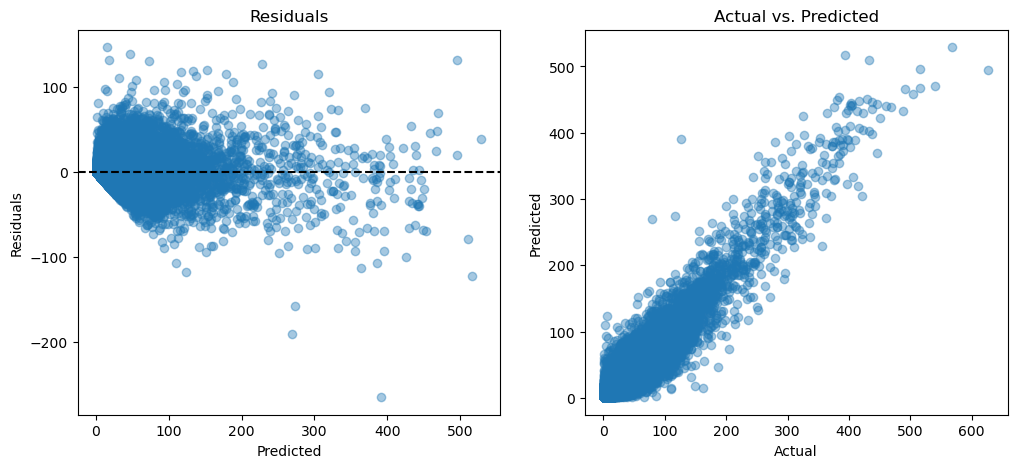

In [13]:
test_predictions = rf.predict(X_test)
analysis(y_test, test_predictions)

In [14]:
import joblib
joblib.dump(rf, 'random_forest_demand.pk1')

['random_forest_demand.pk1']